### **Remote Path**

In [1]:
import sys

sys.path.append('/home/dyuser-e/NI_project_dyuser-e_2026/dynap-se1')


### **Local Path**

In [1]:
import sys
from pathlib import Path

dynapse_path = Path.home() / "NI_project" / "dynap-se1"
sys.path.append(str(dynapse_path))

### **Imports**

In [2]:

import samna
import numpy as np
import matplotlib.pyplot as plt
import samna.dynapse1 as dyn1

import dynapse1utils as ut
from netgen import Neuron, NetworkGenerator

import params
from params import set_params

import time
from IPython.display import Image
from matplotlib.colors import ListedColormap, BoundaryNorm
from matplotlib.patches import Patch

from tools.spikegen_tools import get_instantaneous_activity
from tools.spikegen_tools import generate_regular_rate_spiketrain


### **Remote Connection**

In [ ]:
# get index for board (DONT USE TO CONNECT)

model, _ = ut.open_dynapse1(gui=False, select_device=True)


In [ ]:
# Connecto to board with index
model = ut.open_specific_device_in_sequence(3)

### **Local Connection**

In [3]:
model, _ = ut.open_dynapse1()

[0]:  Bus 1 Device 5 Dynapse1DevKit serial_number 00000033
0 Dynapse1Wrapper created! libcaer init...
Selected device: 00000033
Sender port: tcp://0.0.0.0:34215
Receiver port: tcp://0.0.0.0:51719
Opened device name: Dynapse1DevKit
SamnaNode ID: 1
PythonNode ID: 2
Clearing chip 0... DONE.
Clearing chip 1... DONE.
Clearing chip 2... DONE.
Clearing chip 3... DONE.


In [4]:
# create triplets of indices of neurons to monitor
chip_id = 0

core_neurons = 2
N_neurons    = 8

core_spikegens = 1
N_spikegens    = 1

neuron_ids          = np.arange(1, N_neurons + 1)
neuron_id_triplets  = [(chip_id, core_neurons, n_id) for n_id in neuron_ids]
neurons             = [Neuron(chip, core, nid, False) for chip, core, nid in neuron_id_triplets]

spikegen_ids         = np.arange(1, N_spikegens + 1)
spikegen_id_triplets = [(chip_id, core_spikegens, n_id) for n_id in spikegen_ids]
spikegens            = [Neuron(chip, core, nid, True) for chip, core, nid in spikegen_id_triplets]

print(spikegens)
monitored_neurons = neuron_id_triplets

for triplet in monitored_neurons:
    print(triplet)

event_graph, filter_node, sink_node = ut.create_neuron_select_graph(model, monitored_neurons)
event_graph.start()

[C0c1s1]
(0, 2, 1)
(0, 2, 2)
(0, 2, 3)
(0, 2, 4)
(0, 2, 5)
(0, 2, 6)
(0, 2, 7)
(0, 2, 8)


True

In [5]:
net_gen = NetworkGenerator()
net_gen.clear_network()

synapse_type = dyn1.Dynapse1SynType.AMPA

for neuron in neurons:

    src_neuron = spikegens[0]
    tgt_neuron = neuron

    net_gen.add_connection(src_neuron, tgt_neuron, synapse_type)




### **Parameter Settings**

In [15]:
api = model.get_dynapse1_api()          # get Dynapse1 api from the model
new_config = net_gen.make_dynapse1_configuration()
model.apply_configuration(new_config)

config = model.get_configuration()

param_group0 = config.chips[0].cores[0].parameter_group 
param_group1 = config.chips[0].cores[1].parameter_group 
param_group2 = config.chips[0].cores[2].parameter_group 
param_group3 = config.chips[0].cores[3].parameter_group 

New configuration applied to DYNAP-SE1!


In [7]:
"""Populations on Core : S, I"""

# set AMPA (fast excitatory) weight 
param_group0.param_map['PS_WEIGHT_EXC_F_N'].fine_value   = 110
param_group0.param_map['PS_WEIGHT_EXC_F_N'].coarse_value = 5

# set NMDA (slow excitatory) weight
param_group0.param_map['PS_WEIGHT_EXC_S_N'].fine_value   = 90    
param_group0.param_map['PS_WEIGHT_EXC_S_N'].coarse_value = 5

# set GABA B (slow inhibitory) weight
param_group0.param_map['PS_WEIGHT_INH_S_N'].fine_value   = 100
param_group0.param_map['PS_WEIGHT_INH_S_N'].coarse_value = 5

# set GABA A (fast inhibitory) weight
param_group0.param_map['PS_WEIGHT_INH_F_N'].fine_value =  70      
param_group0.param_map['PS_WEIGHT_INH_F_N'].coarse_value = 5


# set AMPA (fast exc) tau 
param_group0.param_map['NPDPIE_TAU_F_P'].fine_value   = 30      # 50
param_group0.param_map['NPDPIE_TAU_F_P'].coarse_value = 2

# set NMDA (slow exc) tau   
# remember the higher the tau param, the higher the leak, the faster the decay
param_group0.param_map['NPDPIE_TAU_S_P'].fine_value   = 70
param_group0.param_map['NPDPIE_TAU_S_P'].coarse_value = 5

# set GABA A (fast inhibitory) tau                              
param_group0.param_map['NPDPII_TAU_F_P'].fine_value = 40
param_group0.param_map['NPDPII_TAU_F_P'].coarse_value = 4

#GABA B (slow inhibitory) tau
param_group0.param_map['NPDPII_TAU_S_P'].fine_value = 35
param_group0.param_map['NPDPII_TAU_S_P'].coarse_value = 4


# Neuron membrane voltage gain
param_group0.param_map['IF_THR_N'].fine_value = 100
param_group0.param_map['IF_THR_N'].coarse_value = 5

# Refactory period (Base 4, 128?)
param_group0.param_map['IF_RFR_N'].fine_value = 40
param_group0.param_map['IF_RFR_N'].coarse_value = 3

# Bias Current 
param_group0.param_map['IF_DC_P'].fine_value = 20
param_group0.param_map['IF_DC_P'].coarse_value = 0



In [8]:
"""Populations on Core : SpikeGens"""

# set AMPA (fast excitatory) weight 
param_group1.param_map['PS_WEIGHT_EXC_F_N'].fine_value   = 120     #100
param_group1.param_map['PS_WEIGHT_EXC_F_N'].coarse_value = 5

# set NMDA (slow excitatory) weight
param_group1.param_map['PS_WEIGHT_EXC_S_N'].fine_value   = 80    #before 70nottoday
param_group1.param_map['PS_WEIGHT_EXC_S_N'].coarse_value = 5

# set GABA B (slow inhibitory) weight
param_group1.param_map['PS_WEIGHT_INH_S_N'].fine_value   = 100
param_group1.param_map['PS_WEIGHT_INH_S_N'].coarse_value = 5

# set GABA A (fast inhibitory) weight
param_group1.param_map['PS_WEIGHT_INH_F_N'].fine_value =  65      #100
param_group1.param_map['PS_WEIGHT_INH_F_N'].coarse_value = 5



# set AMPA (fast exc) tau 
param_group1.param_map['NPDPIE_TAU_F_P'].fine_value   = 40    #30
param_group1.param_map['NPDPIE_TAU_F_P'].coarse_value = 3

# set NMDA (slow exc) tau   
# remember the higher the tau param, the higher the leak, the faster the decay
param_group1.param_map['NPDPIE_TAU_S_P'].fine_value   = 70
param_group1.param_map['NPDPIE_TAU_S_P'].coarse_value = 5



# set GABA A (fast inhibitory) tau                              #added this
param_group1.param_map['NPDPII_TAU_F_P'].fine_value = 60
param_group1.param_map['NPDPII_TAU_F_P'].coarse_value = 4

#GABA B (slow inhibitory) tau
param_group1.param_map['NPDPII_TAU_S_P'].fine_value = 50
param_group1.param_map['NPDPII_TAU_S_P'].coarse_value = 4



# Neuron membrane voltage gain
param_group1.param_map['IF_THR_N'].fine_value = 100
param_group1.param_map['IF_THR_N'].coarse_value = 5

# Refactory period (Base 4, 128?)
param_group1.param_map['IF_RFR_N'].fine_value = 80
param_group1.param_map['IF_RFR_N'].coarse_value = 2

# Bias Current 
param_group1.param_map['IF_DC_P'].fine_value = 0
param_group1.param_map['IF_DC_P'].coarse_value = 0


In [9]:
"""Populations on Core : T """

# set AMPA (fast excitatory) weight 
param_group2.param_map['PS_WEIGHT_EXC_F_N'].fine_value   = 150
param_group2.param_map['PS_WEIGHT_EXC_F_N'].coarse_value = 5

# set NMDA (slow excitatory) weight
param_group2.param_map['PS_WEIGHT_EXC_S_N'].fine_value   = 100    #before 70
param_group2.param_map['PS_WEIGHT_EXC_S_N'].coarse_value = 5

# set GABA B (slow inhibitory) weight
param_group2.param_map['PS_WEIGHT_INH_S_N'].fine_value   = 100
param_group2.param_map['PS_WEIGHT_INH_S_N'].coarse_value = 5

# set GABA A (fast inhibitory) weight
param_group2.param_map['PS_WEIGHT_INH_F_N'].fine_value =  65      #100
param_group2.param_map['PS_WEIGHT_INH_F_N'].coarse_value = 5



# set AMPA (fast exc) tau 
param_group2.param_map['NPDPIE_TAU_F_P'].fine_value   = 30   #20
param_group2.param_map['NPDPIE_TAU_F_P'].coarse_value = 4

# set NMDA (slow exc) tau   
# remember the higher the tau param, the higher the leak, the faster the decay
param_group2.param_map['NPDPIE_TAU_S_P'].fine_value   = 70
param_group2.param_map['NPDPIE_TAU_S_P'].coarse_value = 5



# set GABA A (fast inhibitory) tau                              #added this
param_group2.param_map['NPDPII_TAU_F_P'].fine_value = 60
param_group2.param_map['NPDPII_TAU_F_P'].coarse_value = 4

#GABA B (slow inhibitory) tau
param_group2.param_map['NPDPII_TAU_S_P'].fine_value = 50
param_group2.param_map['NPDPII_TAU_S_P'].coarse_value = 4



# Neuron membrane voltage gain
param_group2.param_map['IF_THR_N'].fine_value = 50
param_group2.param_map['IF_THR_N'].coarse_value = 4

# Refactory period (Base 4, 128?)
#param_group2.param_map['IF_RFR_N'].fine_value = 10
#param_group2.param_map['IF_RFR_N'].coarse_value = 3

# Bias Current 
param_group2.param_map['IF_DC_P'].fine_value = 0
param_group2.param_map['IF_DC_P'].coarse_value = 0


In [10]:
"""Populations on Core : IIT, IIT, Sum"""

# set AMPA (fast excitatory) weight 
param_group3.param_map['PS_WEIGHT_EXC_F_N'].fine_value   = 100    #max90
param_group3.param_map['PS_WEIGHT_EXC_F_N'].coarse_value = 5

# set NMDA (slow excitatory) weight
param_group3.param_map['PS_WEIGHT_EXC_S_N'].fine_value   = 80    #before 70
param_group3.param_map['PS_WEIGHT_EXC_S_N'].coarse_value = 5

# set GABA B (slow inhibitory) weight
param_group3.param_map['PS_WEIGHT_INH_S_N'].fine_value   = 100       #max120
param_group3.param_map['PS_WEIGHT_INH_S_N'].coarse_value = 5

# set GABA A (fast inhibitory) weight
param_group3.param_map['PS_WEIGHT_INH_F_N'].fine_value =  65      #100
param_group3.param_map['PS_WEIGHT_INH_F_N'].coarse_value = 5



# set AMPA (fast exc) tau 
param_group3.param_map['NPDPIE_TAU_F_P'].fine_value   = 30         #max10
param_group3.param_map['NPDPIE_TAU_F_P'].coarse_value = 3

# set NMDA (slow exc) tau   
# remember the higher the tau param, the higher the leak, the faster the decay
param_group3.param_map['NPDPIE_TAU_S_P'].fine_value   = 70
param_group3.param_map['NPDPIE_TAU_S_P'].coarse_value = 5



# set GABA A (fast inhibitory) tau                              #added this
param_group3.param_map['NPDPII_TAU_F_P'].fine_value = 60           #max20
param_group3.param_map['NPDPII_TAU_F_P'].coarse_value = 4

#GABA B (slow inhibitory) tau
param_group3.param_map['NPDPII_TAU_S_P'].fine_value = 20         #max50
param_group3.param_map['NPDPII_TAU_S_P'].coarse_value = 4       #max3



# Neuron membrane voltage gain
#param_group3.param_map['IF_THR_N'].fine_value = 90
#param_group3.param_map['IF_THR_N'].coarse_value = 5

# Refactory period (Base 4, 128?)
param_group3.param_map['IF_RFR_N'].fine_value = 60
param_group3.param_map['IF_RFR_N'].coarse_value = 4

# Bias Current 
param_group3.param_map['IF_DC_P'].fine_value = 50
param_group3.param_map['IF_DC_P'].coarse_value = 0




In [11]:
model.update_parameter_group(param_group0, 0, 0)
model.update_parameter_group(param_group1, 0, 1)
model.update_parameter_group(param_group2, 0, 2)
model.update_parameter_group(param_group3, 0, 3)

### **Initialize Spike Generator**

Text(0, 0.5, 'spikegen')

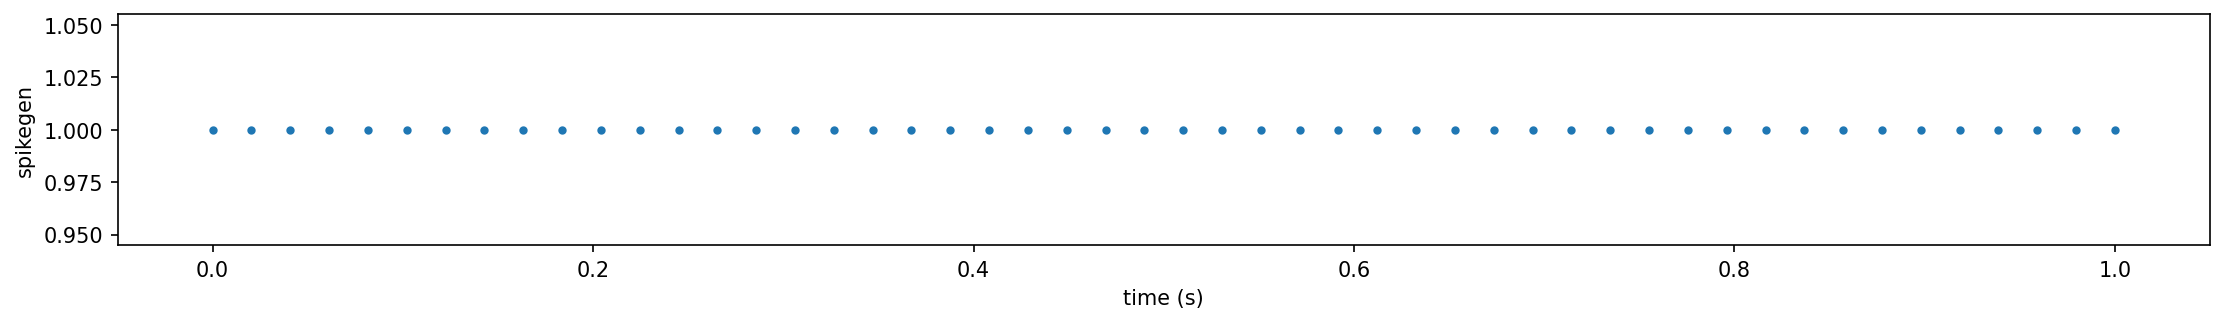

In [12]:
# prepare the spike train that the spike generators will fire
# in our case it will be a sequence of spikes at a fixed rate:


rate_Hz         = 50 #Hz
rates_vector    = (rate_Hz * np.ones(len(spikegen_ids))).astype(int)
fpga_spiketrain = generate_regular_rate_spiketrain(rates_vector, spikegen_ids)   # generate a spiketrain

# plot the prepared spiketrain to verify it is correct
plt.figure(figsize=(18,2), dpi=150)
plt.plot(fpga_spiketrain[:,0], fpga_spiketrain[:,1], '.')
plt.xlabel("time (s)")
plt.ylabel("spikegen")

### **FF Curve Measuremnt**

In [13]:
# Example F-F curve measurement
rec_time = 1      # recording length s

rate_min    = 10  # Hz
rate_max    = 400 # Hz
rate_step   = 10 # Hz

probe_rates = np.arange(rate_min, rate_max, rate_step)
print(probe_rates)

recorded_events = []

[ 10  20  30  40  50  60  70  80  90 100 110 120 130 140 150 160 170 180
 190 200 210 220 230 240 250 260 270 280 290 300 310 320 330 340 350 360
 370 380 390]


In [16]:
# ------------------------------------------------------------
# PREPARE POISSON INPUT
# ------------------------------------------------------------
global_poisson_gen_ids = ut.get_global_id_list(spikegen_ids)
poisson_gen            = model.get_poisson_gen()
poisson_gen.set_chip_id(0)

# set initial rates to zero
for gid in global_poisson_gen_ids:
    poisson_gen.write_poisson_rate_hz(gid, 0)

# ------------------------------------------------------------
# MONITOR NEURONS
# ------------------------------------------------------------
monitored_neurons = neuron_id_triplets
graph, filter_node, sink_node = ut.create_neuron_select_graph(model, monitored_neurons)
graph.start()
# filter_node.set_neurons(monitored_neurons)

# clear buffer
sink_node.get_events()
api.reset_timestamp()

IndexError: invalid index to scalar variable.

In [14]:
rec_time = 1      # recording length [s]

rate_min  = 10    # Hz
rate_max  = 400   # Hz
rate_step = 10    # Hz

probe_rates = np.arange(rate_min, rate_max, rate_step)
print(probe_rates)

recorded_events = []

target_chip    = chip_id
fpga_spike_gen = model.get_fpga_spike_gen()

global_gen_ids = ut.get_global_id_list(spikegens)

for rate in probe_rates:

    rates_vector = (rate * np.ones(len(global_gen_ids))).astype(int)

    fpga_spiketrain = generate_regular_rate_spiketrain(
        rates_vector,
        global_gen_ids
    )

    fpga_spike_gen.stop()

    ut.set_fpga_spike_gen(
        fpga_spike_gen = fpga_spike_gen,
        spike_times    = fpga_spiketrain[:, 0],
        indices        = fpga_spiketrain[:, 1].astype(int),
        target_chips   = [target_chip] * len(fpga_spiketrain),
        isi_base       = 900,
        repeat_mode    = True
    )

    sink_node.get_events()

    fpga_spike_gen.start()
    time.sleep(rec_time)
    fpga_spike_gen.stop()

    events = sink_node.get_events()

    neuron_events = [
        evt for evt in events
        if evt.chip_id == chip_id and evt.core_id == core_neurons
    ]

    spikegen_events = [
        evt for evt in events
        if evt.chip_id == chip_id and evt.core_id == core_spikegens
    ]

    avg_firing_rate = len(neuron_events) / (N_neurons * rec_time)

    print(f"Input rate: {rate} Hz")
    print(f"Spikegen events: {len(spikegen_events)}")
    print(f"Neuron events:   {len(neuron_events)}")
    print(f"Average firing rate: {avg_firing_rate} Hz")

    recorded_events.append(events)

[ 10  20  30  40  50  60  70  80  90 100 110 120 130 140 150 160 170 180
 190 200 210 220 230 240 250 260 270 280 290 300 310 320 330 340 350 360
 370 380 390]


TypeError: 'Neuron' object is not subscriptable

In [ ]:
    
avg_firing_rate = len(events)/(len(monitored_neurons)*rec_time)
print(f"Input rate: {rate} Hz")
print(f"Average firing rate: {avg_firing_rate} Hz")

rates = dict.fromkeys(neurons_ids, 0)
if len(events) > 0:
    for evt in events:
        rates[evt.neuron_id]+=1
    # convert event counts to individual rates by dividing them
    # by the time interval
    for n_id, evt_count in rates.items():
        rates[n_id]=evt_count/rec_time
        
recorded_rates.append(rates)
    

In [127]:
# ------------------------------------------------------------
# NETWORK SETUP
# ------------------------------------------------------------
chip_id = 0

core_neurons   = 2
core_spikegens = 1

N_neurons   = 8
N_spikegens = 1

neuron_ids = [(chip_id, core_neurons, nid) for nid in range(1, N_neurons + 1)]
neurons    = [Neuron(chip, core, nid, False) for chip, core, nid in neuron_ids]

spikegen_ids = [(chip_id, core_spikegens, nid) for nid in range(1, N_spikegens + 1)]
spikegens    = [Neuron(chip, core, nid, True) for chip, core, nid in spikegen_ids]


# ------------------------------------------------------------
# CONNECT SPIKEGEN -> NEURONS
# ------------------------------------------------------------
api     = model.get_dynapse1_api()          # get Dynapse1 api from the model
net_gen = NetworkGenerator()
net_gen.clear_network()

synapse_type = dyn1.Dynapse1SynType.AMPA

for neuron in neurons:
    net_gen.add_connection(spikegens[0], neuron, synapse_type)


# ------------------------------------------------------------
# APPLY CONFIGURATION
# ------------------------------------------------------------
new_config = net_gen.make_dynapse1_configuration()
model.apply_configuration(new_config)

set_params(model, param_group=param_group2)


# ------------------------------------------------------------
# MONITOR REAL NEURONS
# ------------------------------------------------------------
monitored_neurons = neuron_ids

event_graph, filter_node, sink_node = ut.create_neuron_select_graph(
    model,
    monitored_neurons
)

event_graph.start()
sink_node.get_events()
api.reset_timestamp()

In [128]:
# ------------------------------------------------------------
# F-F CURVE MEASUREMENT
# ------------------------------------------------------------
rec_time = 1.0

rate_min  = 10
rate_max  = 400
rate_step = 10

probe_rates = np.arange(rate_min, rate_max, rate_step)

recorded_events = []
out_rates       = []

target_chip          = chip_id
fpga_spike_gen       = model.get_fpga_spike_gen()
global_spikegen_ids  = ut.get_global_id_list(spikegen_ids)

for rate in probe_rates:

    print(f"Input rate: {rate} Hz")

    spike_times  = []
    indices      = []
    target_chips = []

    for gen_id in global_spikegen_ids:

        n_spikes = np.random.poisson(rate * rec_time)
        times    = np.sort(np.random.rand(n_spikes) * rec_time)

        spike_times.extend(times)
        indices.extend([gen_id] * n_spikes)
        target_chips.extend([target_chip] * n_spikes)

    spike_times  = np.array(spike_times)
    indices      = np.array(indices)
    target_chips = np.array(target_chips)

    sort_idx = np.argsort(spike_times)

    spike_times  = spike_times[sort_idx]
    indices      = indices[sort_idx]
    target_chips = target_chips[sort_idx]

    fpga_spike_gen.stop()

    ut.set_fpga_spike_gen(
        fpga_spike_gen = fpga_spike_gen,
        spike_times    = spike_times,
        indices        = indices,
        target_chips   = target_chips,
        isi_base       = 900,
        repeat_mode    = False
    )

    sink_node.get_events()
    api.reset_timestamp()

    fpga_spike_gen.start()
    time.sleep(rec_time)
    fpga_spike_gen.stop()

    events = sink_node.get_events()

    avg_firing_rate = len(events) / (N_neurons * rec_time)

    print(f"Recorded events: {len(events)}")
    print(f"Average firing rate: {avg_firing_rate} Hz")

    recorded_events.append(events)
    out_rates.append(avg_firing_rate)

Input rate: 10 Hz
FpgaSpikeGen already off!
VariableIsiMode already 1
RepeatMode already 0
Recorded events: 1
Average firing rate: 0.125 Hz
Input rate: 20 Hz
FpgaSpikeGen already off!
VariableIsiMode already 1
RepeatMode already 0
Recorded events: 0
Average firing rate: 0.0 Hz
Input rate: 30 Hz
FpgaSpikeGen already off!
VariableIsiMode already 1
RepeatMode already 0
Recorded events: 1
Average firing rate: 0.125 Hz
Input rate: 40 Hz
FpgaSpikeGen already off!
VariableIsiMode already 1
RepeatMode already 0
Recorded events: 0
Average firing rate: 0.0 Hz
Input rate: 50 Hz
FpgaSpikeGen already off!
VariableIsiMode already 1
RepeatMode already 0
Recorded events: 1
Average firing rate: 0.125 Hz
Input rate: 60 Hz
FpgaSpikeGen already off!
VariableIsiMode already 1
RepeatMode already 0
Recorded events: 0
Average firing rate: 0.0 Hz
Input rate: 70 Hz
FpgaSpikeGen already off!
VariableIsiMode already 1
RepeatMode already 0
Recorded events: 1
Average firing rate: 0.125 Hz
Input rate: 80 Hz
FpgaSpik

Text(0, 0.5, 'Mean Firing Rate')

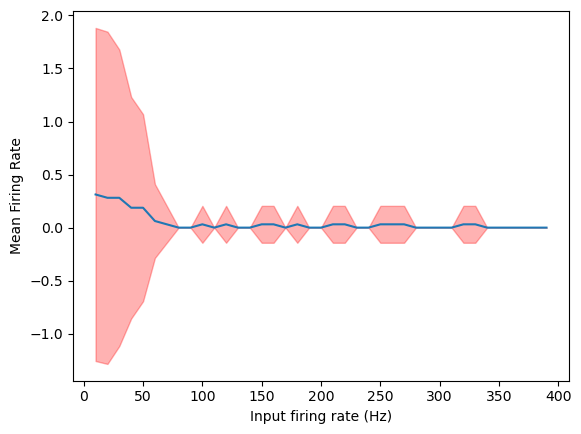

In [31]:
## store and plot the firing rate recordings

x_labels        = np.arange(rate_min, rate_max, rate_step)
mean_y_labels   = []
std_y_labels    = []

for line, fine in zip(recorded_rates, x_labels):
    rates = np.fromiter(line.values(), dtype=float)
    #print(line.values())
    mean_rate   = rates.mean()
    std_rate    = rates.std()
    
    mean_y_labels.append(mean_rate)
    std_y_labels.append(std_rate)
    
plt.figure()
plt.plot(x_labels, mean_y_labels)
plt.fill_between(x_labels,np.array(mean_y_labels)- np.array(std_y_labels), np.array(mean_y_labels) + np.array(std_y_labels), alpha = 0.3, color = 'red')
plt.xlabel('Input firing rate (Hz)')
plt.ylabel('Mean Firing Rate')

### **Spike Adaptation Measuremtn**

In [ ]:
# Enable the adaptation circuit
ut.set_adaptation_enable(model, chip_id, core_id, 1716, bias_format='index')

# Set the adaptation parameters - decay, weight and gain
ut.set_neuron_adaptation_tau(model, chip_id, core_id, 987, bias_format='index')
ut.set_neuron_adaptation_weight(model, chip_id, core_id, 1666, bias_format='index')
ut.set_neuron_adaptation_gain(model, chip_id, core_id, 1037, bias_format='index')

In [ ]:
rate = 300 #hz

rates_vector = (rate*np.ones(len(neurons_ids))).astype(int)
fpga_spiketrain = generate_regular_rate_spiketrain(rates_vector, neurons_ids)

# stop the spikegen while it is being reset
fpga_spike_gen.stop()
ut.set_fpga_spike_gen(fpga_spike_gen,
                  spike_times=fpga_spiketrain[:,0],
                  indices=fpga_spiketrain[:,1].astype(int),
                  target_chips=[target_chip]*len(fpga_spiketrain),
                  isi_base=900,
                  repeat_mode=False)


VariableIsiMode already 1


Text(0, 0.5, 'neuron ID ')

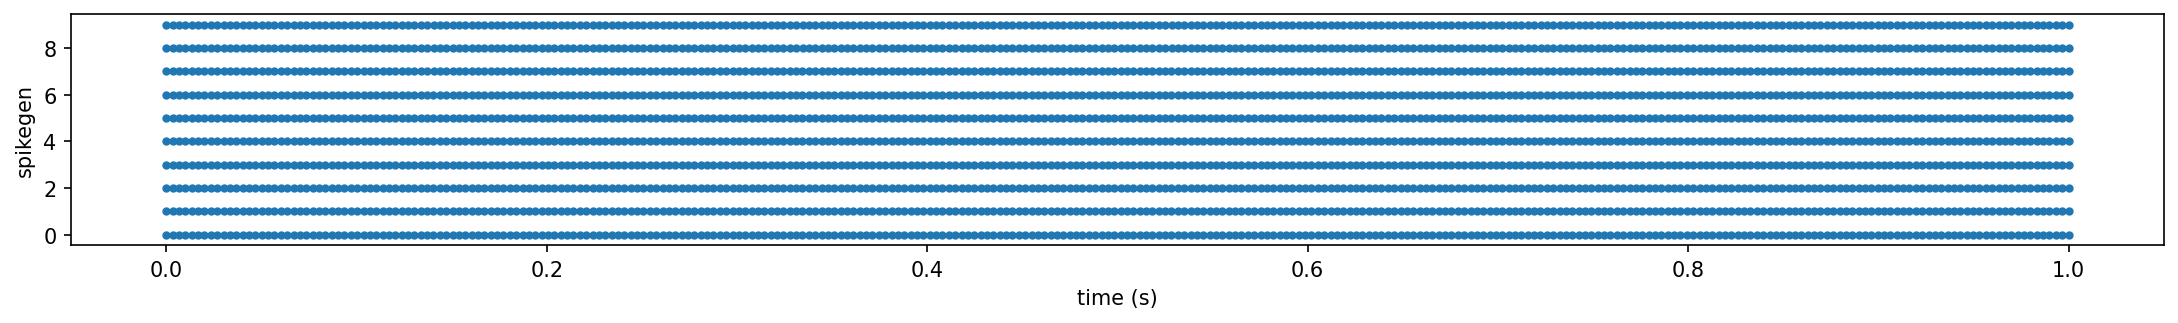

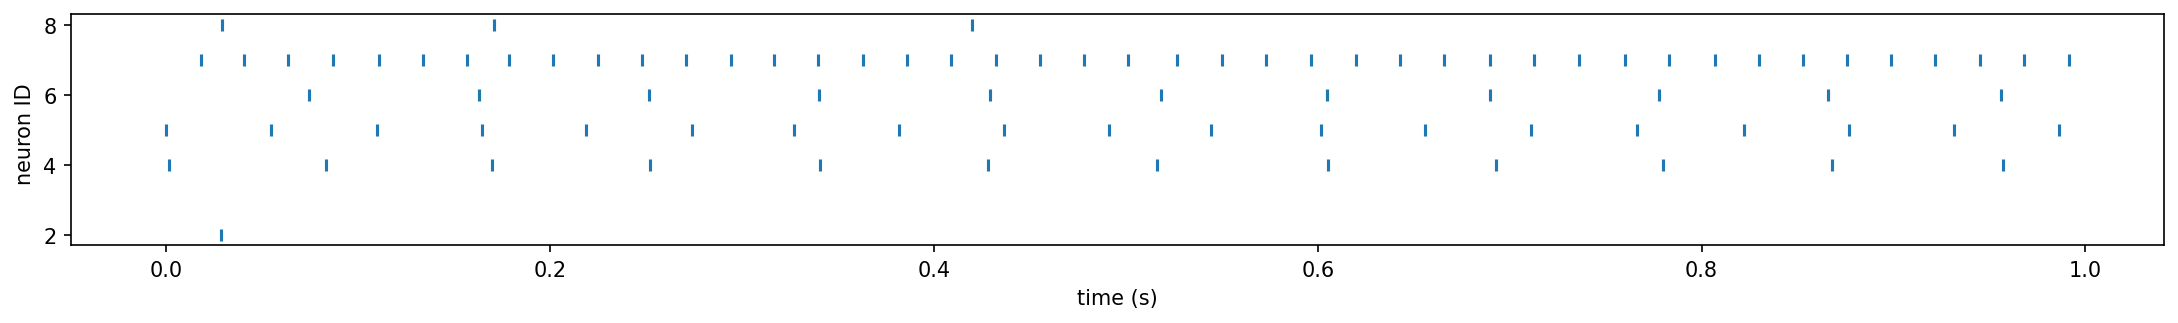

In [ ]:
pre_stim_time=0.0 #s
stim_time=1 #s
post_stim_time=0 #s

#ut.set_neuron_adaptation_tau(model, chip_id, core_id, (4, 110))
#ut.set_neuron_adaptation_weight(model, chip_id, core_id, (7, 110))
#ut.set_neuron_adaptation_threshold(model, chip_id, core_id, (4, 150))

#reset the recording
sink_node.get_events()

#wait for any dynamics to stabilize
time.sleep(pre_stim_time)

#start the pulse
fpga_spike_gen.start()
time.sleep(stim_time)

#stop the pulse
fpga_spike_gen.stop()

# wait a bit more after the stimulus is off
time.sleep(post_stim_time)

#get_the events
events = sink_node.get_events()

# sort and plot the events
event_ids = np.array([evt.neuron_id for evt in events])
timestamps_us = np.array([evt.timestamp for evt in events])
timestamps_us[:]-=timestamps_us[0]
timestamps_s = timestamps_us*1e-06


plt.figure(figsize=(18,2), dpi=150)
plt.plot(fpga_spiketrain[:,0], fpga_spiketrain[:,1], '.')
plt.xlabel("time (s)")
plt.ylabel("spikegen")

plt.figure(figsize=(18,2), dpi=150)
plt.scatter(timestamps_s, event_ids, marker='|')
plt.xlabel("time (s)")
plt.ylabel("neuron ID ")

Text(0, 0.5, 'Activity (Hz)')

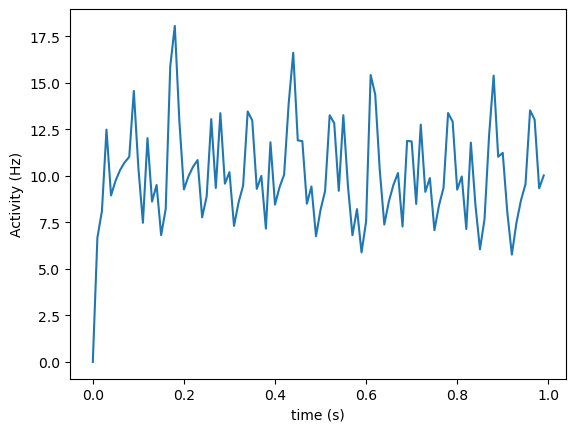

In [ ]:
activity_dt = 0.01 #s
exp_time_constant = 0.03 #s

activity, activity_t = get_instantaneous_activity(timestamps_s,
                                                        activity_dt,
                                                        exp_time_constant)

activity = activity/len(neurons_ids)

plt.plot(activity_t, activity)
plt.xlabel("time (s)")
plt.ylabel("Activity (Hz)")